# CSCE 676 — Project Checkpoint 1

**Student:** Paurushmani Singh 
**UIN:** 627005078 
**Date:** February 2026

---

## Collaboration Declaration

1. **Collaborators:** None 
2. **Web Sources:** CMU MoCap documentation (mocap.cs.cmu.edu), NASA C-MAPSS documentation (data.nasa.gov), UCI ML Repository (archive.ics.uci.edu) 
3. **AI Tools:** Claude (Anthropic) — used for structuring the notebook and assisting with EDA code 
4. **Citations:** A. Saxena, K. Goebel, D. Simon, and N. Eklund, "Damage Propagation Modeling for Aircraft Engine Run-to-Failure Simulation," in Proc. 1st Int. Conf. on Prognostics and Health Management (PHM), 2008.

# (A) Identification of Candidate Datasets

## Dataset 1: CMU Motion Capture Database

- **Dataset name and source:** CMU Motion Capture Database — [mocap.cs.cmu.edu](http://mocap.cs.cmu.edu/), also available on [Kaggle](https://www.kaggle.com/datasets/kmader/cmu-mocap)
- **Course topic alignment:** Clustering (grouping motion types such as walking, running, dancing) and Anomaly Detection (identifying unusual or atypical movements)
- **Potential beyond-course techniques:** Dynamic Time Warping (DTW) for measuring similarity between motion sequences of different lengths — not covered in lecture
- **Dataset size and structure:** 2,605 motion trials from ~140 subjects; each frame has 62 degrees of freedom (3D root position + 59 joint angles) recorded at 120 fps
- **Data types:** Joint angles (Euler angles), 3D root translation, subject IDs, motion category labels (walking, running, jumping, dancing, sports, etc.)
- **Target variable(s):** None (unsupervised pattern mining) — motion category labels are available for validation of clustering results
- **Licensing or usage constraints:** No restrictive license; free for research and commercial use; only restriction is that the data cannot be resold directly

## Dataset 2: NASA C-MAPSS Turbofan Engine Degradation

- **Dataset name and source:** C-MAPSS (Commercial Modular Aero-Propulsion System Simulation) — [NASA Prognostics Data Repository](https://data.nasa.gov/dataset/cmapss-jet-engine-simulated-data), also on [Kaggle](https://www.kaggle.com/datasets/behrad3d/nasa-cmaps)
- **Course topic alignment:** Anomaly Detection (detecting engine degradation onset) and Streaming/time-series analysis
- **Potential beyond-course techniques:** Remaining Useful Life (RUL) prediction using LSTM networks — not covered in lecture
- **Dataset size and structure:** FD001 subset has ~20,631 rows across 100 engines; 26 columns (engine ID, cycle number, 3 operational settings, 21 sensor measurements); run-to-failure trajectories
- **Data types:** Engine unit ID, time cycle (integer), operational settings (continuous), sensor measurements (temperature, pressure, speed, flow ratios)
- **Target variable(s):** Remaining Useful Life (RUL) — derived from the run-to-failure data (each engine runs until failure, so RUL = max_cycle - current_cycle)
- **Licensing or usage constraints:** No restrictive license; U.S. Government Public Domain

## Dataset 3: AI4I 2020 Predictive Maintenance Dataset

- **Dataset name and source:** AI4I 2020 Predictive Maintenance Dataset — [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/601/ai4i+2020+predictive+maintenance+dataset), also on [Kaggle](https://www.kaggle.com/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020)
- **Course topic alignment:** Clustering (grouping failure patterns) and Frequent Pattern Mining (identifying common co-occurring failure conditions)
- **Potential beyond-course techniques:** SHAP-based model explainability for failure prediction — not covered in lecture
- **Dataset size and structure:** 10,000 rows, 14 columns; tabular CSV format (~500 KB)
- **Data types:** Air temperature (K), process temperature (K), rotational speed (rpm), torque (Nm), tool wear (min), product quality type (L/M/H), binary failure flags
- **Target variable(s):** Machine failure (binary) and 5 individual failure mode flags (Tool Wear, Heat Dissipation, Power, Overstrain, Random)
- **Licensing or usage constraints:** No restrictive license; CC BY 4.0

# (B) Comparative Analysis of Datasets

| Dimension | CMU Motion Capture | NASA C-MAPSS (FD001) | AI4I 2020 Predictive Maintenance |
|---|---|---|---|
| **Supported data mining tasks** | Clustering motion types (e.g., walking vs. dancing), anomaly detection for unusual movements (course); Dynamic Time Warping for comparing variable-length motion sequences (beyond course) | Anomaly detection for engine degradation onset, streaming time-series analysis (course); LSTM-based Remaining Useful Life prediction (beyond course) | Clustering failure patterns, frequent pattern mining on co-occurring failure conditions (course); SHAP-based model explainability (beyond course) |
| **Data quality issues** | 4 joints have zero variance (clavicles, fingers) and must be removed; several joints show extreme outlier angles (root up to 729°, rthumb up to 625°) that are likely cumulative rotations needing normalization; sequences vary from 128 to 4,510 frames — requires handling variable-length inputs | 7 out of 21 sensors are completely constant (std = 0) and must be removed, leaving 14 informative sensors; sensor_6 is borderline (std = 0.001); data is simulated, not from real engines | No missing values; severe class imbalance (only 3.4% failures); 9 samples are flagged as failure but have no failure type assigned (data inconsistency); rotational speed is heavily right-skewed (skew = 2.0) with 164 outliers |
| **Algorithmic feasibility** | 2,605 trials × 62 DOF is manageable; pairwise DTW is O(n²) per pair but feasible with FastDTW on this scale; PCA and k-means straightforward on summary features per trial | 20,631 rows across 100 engines is small — all standard algorithms run in seconds without Spark; 14 informative sensors with strong correlation to RUL (top abs(r) = 0.70) make prediction feasible | Very small (10,000 × 14); all algorithms trivially feasible; however weak feature-target correlations (max abs(r) = 0.19) may limit prediction performance |
| **Bias considerations** | Subjects are predominantly able-bodied adults from a university setting; limited demographic diversity in body types; motion categories are unevenly distributed (some have many trials, others very few) | Simulated data from C-MAPSS software — no real-world operational bias, but single operating condition (sea level) in FD001 limits generalizability | Synthetic data where low-quality products (Type L) fail almost 2× more than high-quality (3.9% vs 2.1%); this is by design but doesn't capture real manufacturing complexity |
| **Ethical considerations** | Low risk — anonymized skeletal motion data with no PII; could theoretically be used for surveillance-related gait analysis, but dataset itself poses no direct harm | Low risk — simulated engine data; no human subjects; could support safety-critical predictive maintenance applications | Low risk — entirely synthetic manufacturing data; no connection to real workers or facilities; predictive maintenance applications are generally beneficial |

# (C) Dataset Selection

**Selected Dataset:** NASA C-MAPSS Turbofan Engine Degradation (FD001)

**Reasons:**
- Directly supports **anomaly detection** (course topic): degradation onset can be detected as a deviation from healthy engine behavior, and 14 informative sensors provide a rich multivariate signal for identifying anomalous operating states
- Supports **streaming/time-series analysis** (course topic): each engine's sensor readings form a natural data stream where patterns evolve over time
- Enables a meaningful beyond-course technique: **autoencoder-based anomaly detection** — training an autoencoder on healthy engine cycles and using reconstruction error to flag degradation, a technique not covered in lecture
- Clean, well-structured data that loads directly into pandas (space-separated text); no missing values; 20,631 rows across 100 engines is large enough to be interesting but small enough to iterate quickly
- Degradation trends are visually compelling — sensors show clear drift as engines approach failure, making EDA observations and hypotheses straightforward to motivate

**Trade-offs:**
- Simulated data from the C-MAPSS software rather than real engine measurements — findings may not generalize to actual turbofan engines
- FD001 uses a single operating condition (sea level) and a single fault mode (HPC degradation), which simplifies the problem but limits the complexity of discoverable patterns
- No text or graph component — limits opportunities for text mining or graph-based techniques
- Very commonly used as a benchmark dataset — less distinctive for a portfolio compared to a more unique dataset like CMU MoCap

# (D) Exploratory Data Analysis — NASA C-MAPSS (FD001)

We focus on the FD001 subset: 100 engines run to failure under a single operating condition (sea level) with a single fault mode (HPC degradation). Each row is one operational cycle for one engine, with 21 sensor measurements and 3 operational settings.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Column names — the dataset has no header
col_names = ['unit', 'cycle'] + [f'setting_{i}' for i in range(1, 4)] + [f'sensor_{i}' for i in range(1, 22)]

train = pd.read_csv(
    'data/6. Turbofan Engine Degradation Simulation Data Set/train_FD001.txt',
    sep=r'\s+', header=None, names=col_names
)

# Derive Remaining Useful Life (RUL) for each row:
# RUL = (max cycle for that engine) - (current cycle)
max_cycles = train.groupby('unit')['cycle'].max()
train['RUL'] = train.apply(lambda row: max_cycles[row['unit']] - row['cycle'], axis=1)

print(f"Shape: {train.shape}")
print(f"Number of engines: {train['unit'].nunique()}")
print(f"\nFirst 5 rows:")
train.head()

Shape: (20631, 27)
Number of engines: 100

First 5 rows:


,unit,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191.0
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190.0
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189.0
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188.0
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187.0


## D.1 Data Basics and Quality

We check data types, missing values, and identify constant (uninformative) sensors.

In [2]:
# Data types and missing values
print("Data types:")
print(train.dtypes.value_counts())
print(f"\nMissing values: {train.isnull().sum().sum()}")
print(f"Duplicate rows: {train.duplicated().sum()}")

# Identify constant sensors (std < 0.01) — these carry no information
print("\n--- Sensor variance analysis ---")
sensor_cols = [c for c in train.columns if c.startswith('sensor_')]
setting_cols = [c for c in train.columns if c.startswith('setting_')]

constant_cols = []
informative_cols = []

for col in setting_cols + sensor_cols:
    std = train[col].std()
    if std < 0.01:
        constant_cols.append(col)
        print(f"  CONSTANT  {col}: std={std:.6f}, value={train[col].iloc[0]}")
    else:
        informative_cols.append(col)

print(f"\nConstant columns to drop: {len(constant_cols)} -> {constant_cols}")
print(f"Informative columns kept: {len(informative_cols)} -> {informative_cols}")

Data types:
float64    23
int64       4
Name: count, dtype: int64

Missing values: 0
Duplicate rows: 0

--- Sensor variance analysis ---
  CONSTANT  setting_1: std=0.002187, value=-0.0007
  CONSTANT  setting_2: std=0.000293, value=-0.0004
  CONSTANT  setting_3: std=0.000000, value=100.0
  CONSTANT  sensor_1: std=0.000000, value=518.67
  CONSTANT  sensor_5: std=0.000000, value=14.62
  CONSTANT  sensor_6: std=0.001389, value=21.61
  CONSTANT  sensor_10: std=0.000000, value=1.3
  CONSTANT  sensor_16: std=0.000000, value=0.03
  CONSTANT  sensor_18: std=0.000000, value=2388
  CONSTANT  sensor_19: std=0.000000, value=100.0

Constant columns to drop: 10 -> ['setting_1', 'setting_2', 'setting_3', 'sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
Informative columns kept: 14 -> ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


**Observation:** There are no missing values or duplicates. All 3 operational settings and 7 sensors have near-zero variance (std < 0.01) — 10 columns total remain constant throughout every engine's lifetime and provide no discriminative signal. We drop these before further analysis, leaving 14 informative sensor columns.

**Decision:** We use a threshold of std < 0.01 to identify constant columns. This is a conservative cutoff — sensor_6 (std = 0.001) and the operational settings (setting_1 std = 0.002, setting_2 std = 0.0003) are borderline but carry effectively no information compared to the remaining sensors. The settings being near-constant is consistent with FD001 operating under a single flight condition.

In [3]:
# Drop constant columns
train_clean = train.drop(columns=constant_cols)
print(f"Shape after dropping constant columns: {train_clean.shape}")
print(f"\nDescriptive statistics for informative sensors:")
train_clean[informative_cols].describe().round(3)

Shape after dropping constant columns: (20631, 17)

Descriptive statistics for informative sensors:


,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
count,20631.000,20631.000,20631.000,20631.000,20631.000,20631.000,20631.000,20631.000,20631.000,20631.000,20631.000,20631.000,20631.000,20631.000
mean,642.681,1590.523,1408.934,553.368,2388.097,9065.243,47.541,521.413,2388.096,8143.753,8.442,393.211,38.816,23.290
std,0.500,6.131,9.001,0.885,0.071,22.083,0.267,0.738,0.072,19.076,0.038,1.549,0.181,0.108
min,641.210,1571.040,1382.250,549.850,2387.900,9021.730,46.850,518.690,2387.880,8099.940,8.325,388.000,38.140,22.894
25%,642.325,1586.260,1402.360,552.810,2388.050,9053.100,47.350,520.960,2388.040,8133.245,8.415,392.000,38.700,23.222
50%,642.640,1590.100,1408.040,553.440,2388.090,9060.660,47.510,521.480,2388.090,8140.540,8.439,393.000,38.830,23.298
75%,643.000,1594.380,1414.555,554.010,2388.140,9069.420,47.700,521.950,2388.140,8148.310,8.466,394.000,38.950,23.367
max,644.530,1616.910,1441.490,556.060,2388.560,9244.590,48.530,523.380,2388.560,8293.720,8.585,400.000,39.430,23.618


## D.2 Data Validation

Before proceeding with analysis, we run sanity checks to verify that data loading, RUL derivation, and preprocessing are correct.

In [4]:
# --- Data Validation ---
# These assertions verify that data loading and preprocessing are correct.

# 1. Correct number of engines
assert train['unit'].nunique() == 100, "Expected 100 engines in FD001"

# 2. No missing values after loading
assert train.isnull().sum().sum() == 0, "Unexpected missing values"

# 3. Cycles start at 1 for every engine
assert (train.groupby('unit')['cycle'].min() == 1).all(), "All engines should start at cycle 1"

# 4. Cycles are consecutive (no gaps) for each engine
for uid in train['unit'].unique():
    engine = train[train['unit'] == uid]['cycle'].values
    assert np.array_equal(engine, np.arange(1, len(engine) + 1)), f"Engine {uid} has non-consecutive cycles"

# 5. RUL = 0 at the last cycle of each engine (i.e., failure point)
last_cycles = train.groupby('unit').tail(1)
assert (last_cycles['RUL'] == 0).all(), "RUL should be 0 at the last cycle (failure)"

# 6. RUL is monotonically decreasing within each engine
for uid in train['unit'].unique():
    rul = train[train['unit'] == uid]['RUL'].values
    assert np.all(np.diff(rul) == -1), f"Engine {uid} RUL is not monotonically decreasing"

# 7. Correct number of columns after dropping constants
assert len(informative_cols) == 14, f"Expected 14 informative columns, got {len(informative_cols)}"
assert train_clean.shape[1] == 17, f"Expected 17 columns (unit + cycle + 14 sensors + RUL), got {train_clean.shape[1]}"

# 8. No constant columns remain in the cleaned data
for col in informative_cols:
    assert train_clean[col].std() > 0.01, f"{col} should not be constant"

print("All 8 validation checks passed.")

All 8 validation checks passed.


## D.3 Engine Lifetime Distribution

Each engine in the training set runs until failure. The number of cycles before failure (engine lifetime) tells us how much data we have per engine and how variable the failure times are.

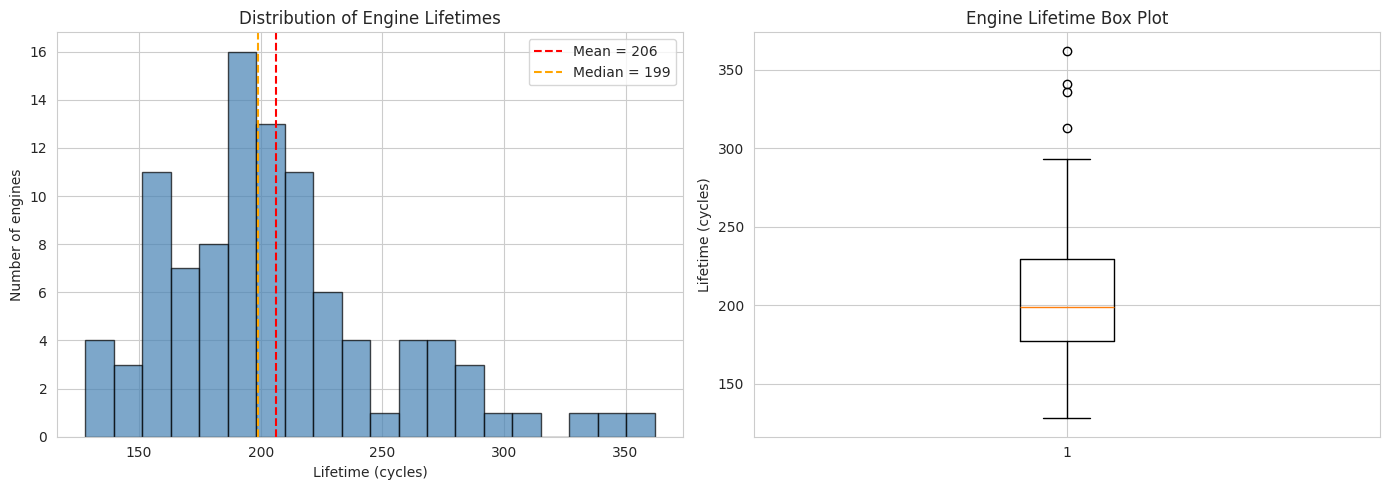

Lifetime statistics:
  Mean: 206.3 cycles
  Std:  46.3 cycles
  Min:  128 cycles
  Max:  362 cycles
  IQR:  [177, 229]


In [5]:
# Engine lifetime distribution
lifetimes = train.groupby('unit')['cycle'].max()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(lifetimes, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(lifetimes.mean(), color='red', linestyle='--', label=f'Mean = {lifetimes.mean():.0f}')
axes[0].axvline(lifetimes.median(), color='orange', linestyle='--', label=f'Median = {lifetimes.median():.0f}')
axes[0].set_xlabel('Lifetime (cycles)')
axes[0].set_ylabel('Number of engines')
axes[0].set_title('Distribution of Engine Lifetimes')
axes[0].legend()

# Box plot
axes[1].boxplot(lifetimes, vert=True)
axes[1].set_ylabel('Lifetime (cycles)')
axes[1].set_title('Engine Lifetime Box Plot')

plt.tight_layout()
plt.show()

print(f"Lifetime statistics:")
print(f"  Mean: {lifetimes.mean():.1f} cycles")
print(f"  Std:  {lifetimes.std():.1f} cycles")
print(f"  Min:  {lifetimes.min()} cycles")
print(f"  Max:  {lifetimes.max()} cycles")
print(f"  IQR:  [{lifetimes.quantile(0.25):.0f}, {lifetimes.quantile(0.75):.0f}]")

**Observation:** Engine lifetimes range from 128 to 362 cycles with a mean of ~206 and moderate spread (std ~46). The distribution is roughly symmetric with a slight right skew — a few engines survive significantly longer. This means some engines provide much more training data than others, which is worth considering when building models.

## D.4 Sensor Degradation Curves

The key characteristic of this dataset is that sensors drift as engines degrade. We plot sensor readings over an engine's lifetime for a few representative engines to visualize this degradation pattern.

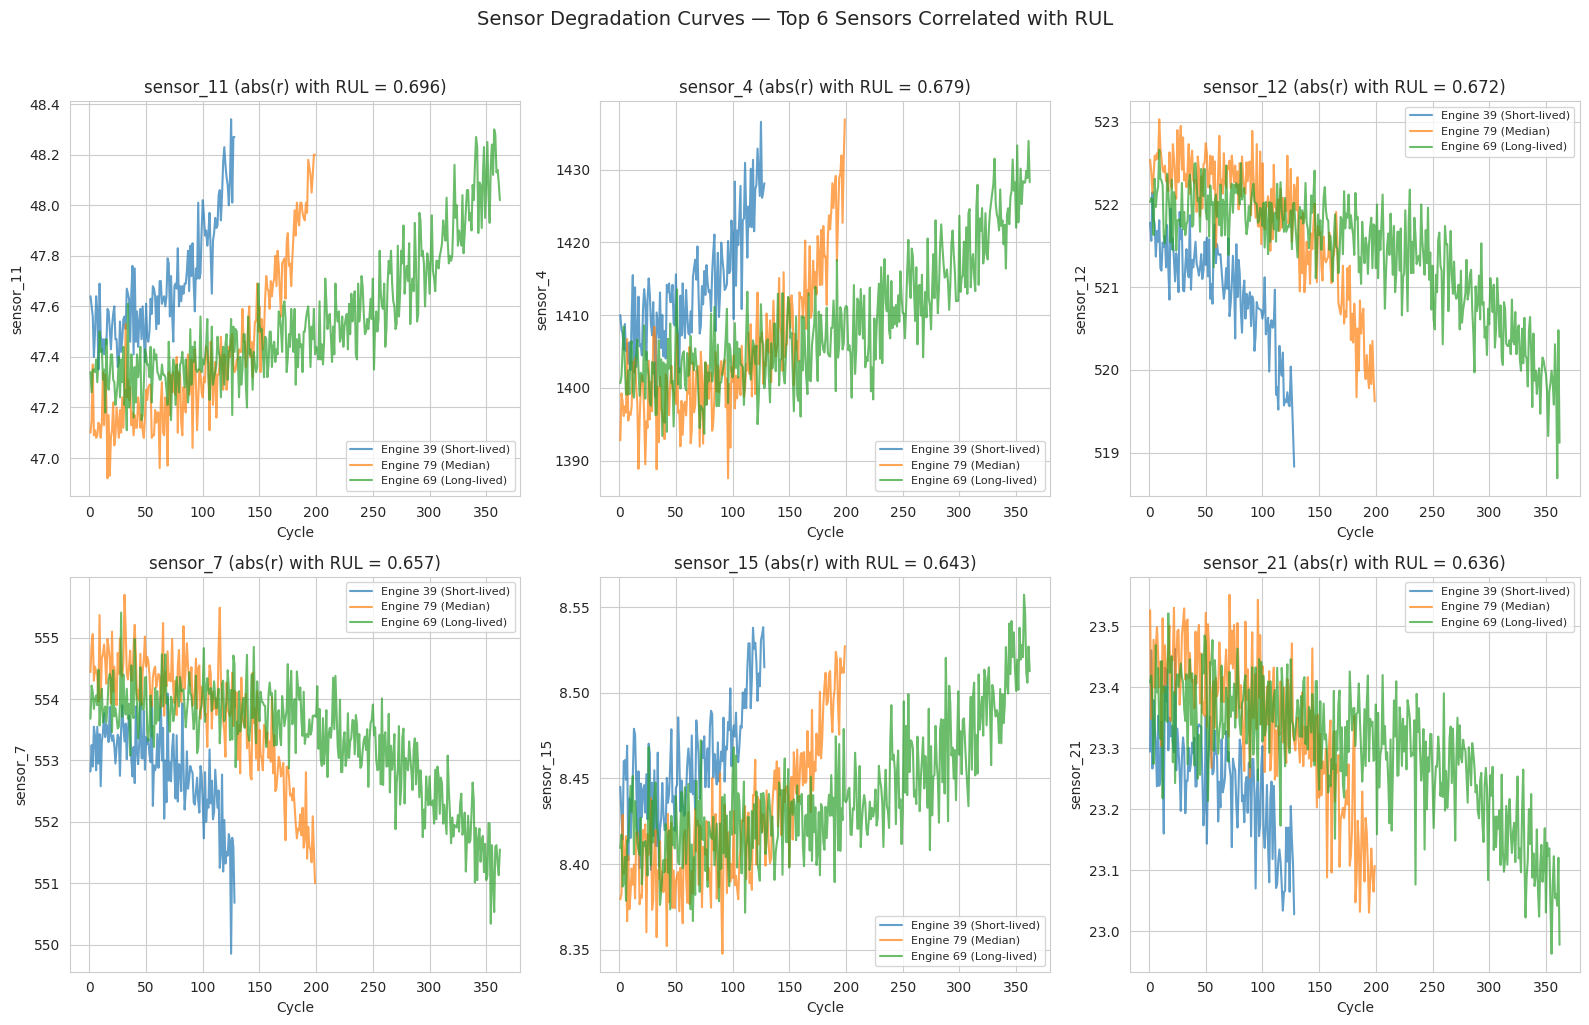

In [6]:
# Select 3 representative engines: short, medium, and long lifetime
sorted_lifetimes = lifetimes.sort_values()
short_engine = sorted_lifetimes.index[0]       # shortest lifetime
mid_engine = sorted_lifetimes.index[len(sorted_lifetimes)//2]  # median lifetime
long_engine = sorted_lifetimes.index[-1]        # longest lifetime

engines = [short_engine, mid_engine, long_engine]
labels = ['Short-lived', 'Median', 'Long-lived']

# Plot degradation curves for the top 6 most correlated sensors
corr_with_rul = train_clean[informative_cols + ['RUL']].corr()['RUL'].drop('RUL').abs().sort_values(ascending=False)
top_sensors = corr_with_rul.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, sensor in enumerate(top_sensors):
    for engine, label in zip(engines, labels):
        engine_data = train_clean[train_clean['unit'] == engine]
        axes[i].plot(engine_data['cycle'], engine_data[sensor], label=f'Engine {engine} ({label})', alpha=0.7)
    axes[i].set_xlabel('Cycle')
    axes[i].set_ylabel(sensor)
    axes[i].set_title(f'{sensor} (abs(r) with RUL = {corr_with_rul[sensor]:.3f})')
    axes[i].legend(fontsize=8)

plt.suptitle('Sensor Degradation Curves — Top 6 Sensors Correlated with RUL', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Observation:** The top sensors (sensor_11, sensor_4, sensor_12, sensor_7, sensor_15, sensor_21) show clear monotonic degradation trends — they drift steadily as engines approach failure. Sensor noise is substantial (visible as jagged lines), which motivates the use of rolling window smoothing in later analysis. The degradation pattern is consistent across engines but with different starting points and rates, confirming that anomaly detection and RUL prediction are viable tasks.

## D.5 Sensor Correlation Analysis

We examine how sensors correlate with each other and with the derived RUL target to identify redundancy and select the most predictive features.

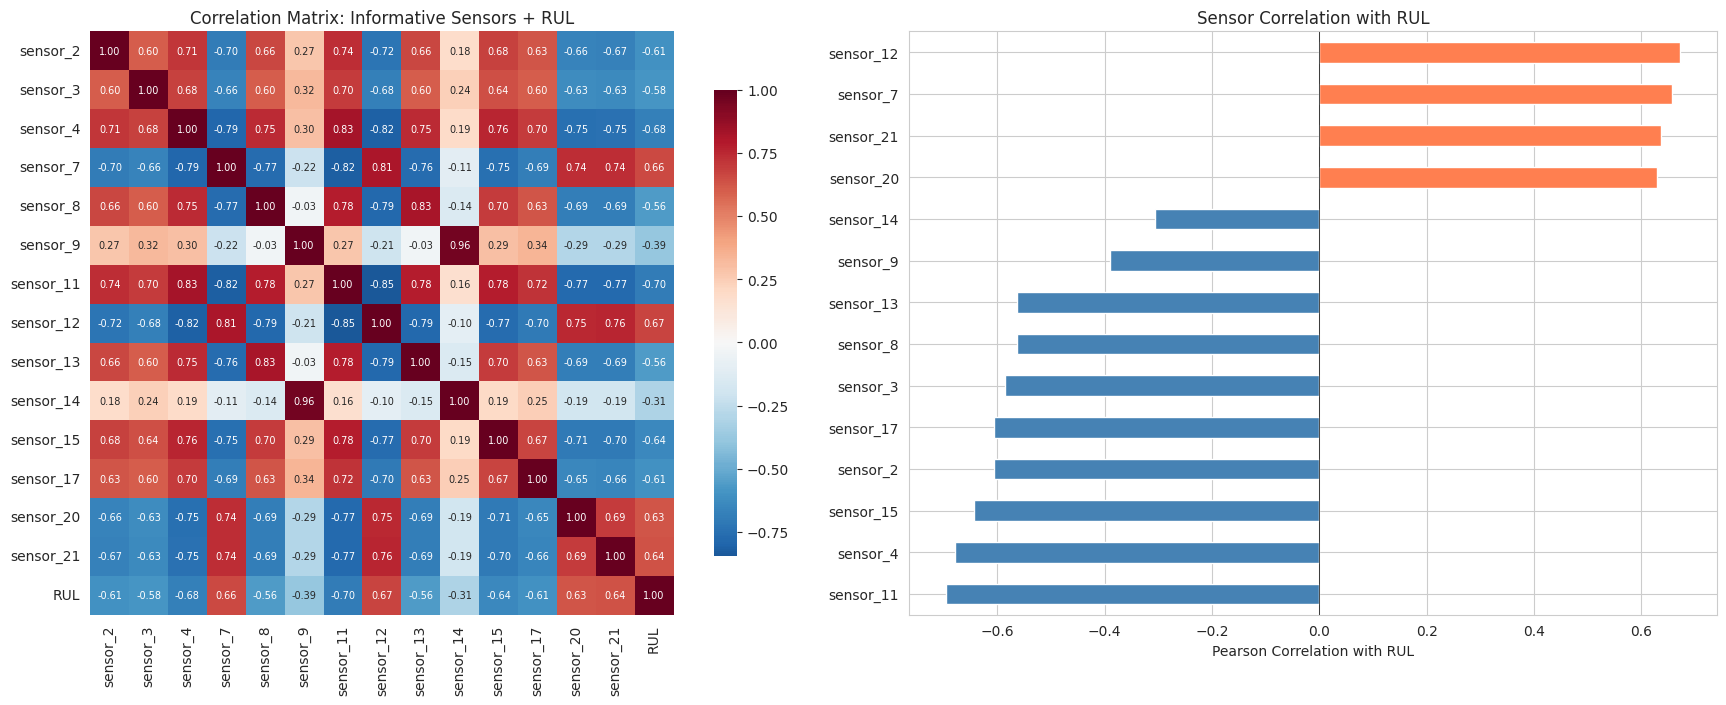

In [7]:
# Correlation heatmap: informative sensors + RUL
corr_matrix = train_clean[informative_cols + ['RUL']].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Full heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, ax=axes[0], cbar_kws={'shrink': 0.8}, annot_kws={'size': 7})
axes[0].set_title('Correlation Matrix: Informative Sensors + RUL')

# Bar chart of absolute correlation with RUL
rul_corr = corr_matrix['RUL'].drop('RUL').sort_values()
colors = ['steelblue' if v < 0 else 'coral' for v in rul_corr]
rul_corr.plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_xlabel('Pearson Correlation with RUL')
axes[1].set_title('Sensor Correlation with RUL')
axes[1].axvline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

**Observation:** Several sensor pairs are highly correlated with each other (e.g., sensor_8 and sensor_13 are near-identical), indicating redundancy. Sensors split into two groups: those that increase with degradation (negative correlation with RUL, such as sensor_4, sensor_11) and those that decrease (positive correlation with RUL, such as sensor_7, sensor_15). The strongest individual correlations with RUL are around abs(r) = 0.60–0.70, suggesting that no single sensor is a perfect predictor — multi-sensor approaches will be needed.

## D.6 Sensor Distributions

We examine the distribution of each informative sensor to understand their scales, skewness, and potential outliers.

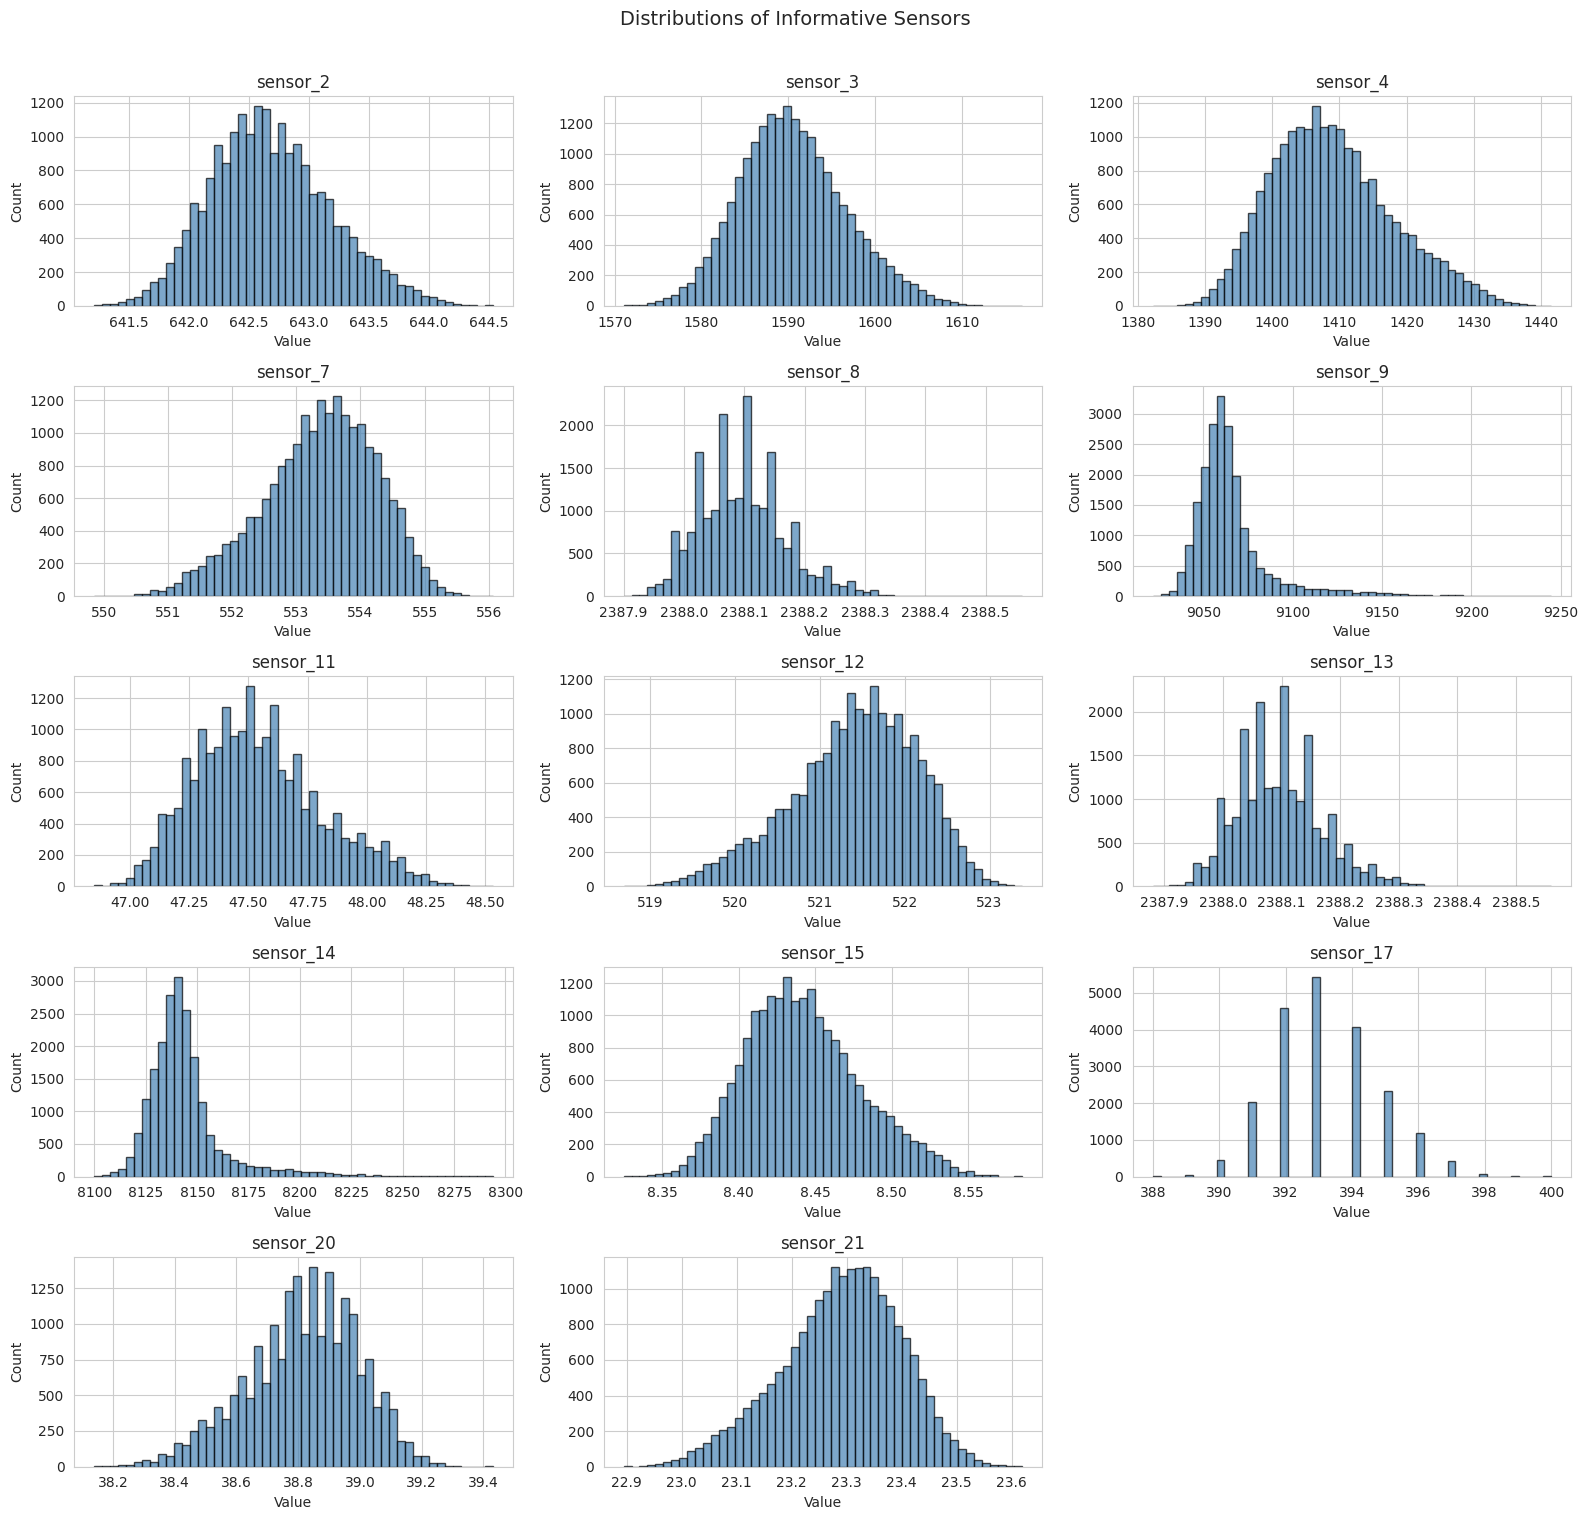

In [8]:
# Distribution of all informative sensors
n_cols = 3
n_rows = (len(informative_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(informative_cols):
    axes[i].hist(train_clean[col], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distributions of Informative Sensors', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Observation:** Sensor scales vary dramatically — sensor_9 ranges in the 9,000s while sensor_15 is around 8.3–8.6. This confirms that normalization (e.g., Min-Max scaling) is essential before applying distance-based algorithms like clustering or autoencoders. Most sensors show roughly symmetric distributions with some showing slight bimodality (mixing healthy and degraded states).

## D.7 Early vs. Late Life Comparison

To understand how sensors behave differently when engines are healthy vs. near failure, we compare sensor readings from the first 20 cycles (healthy) against the last 20 cycles (near failure).

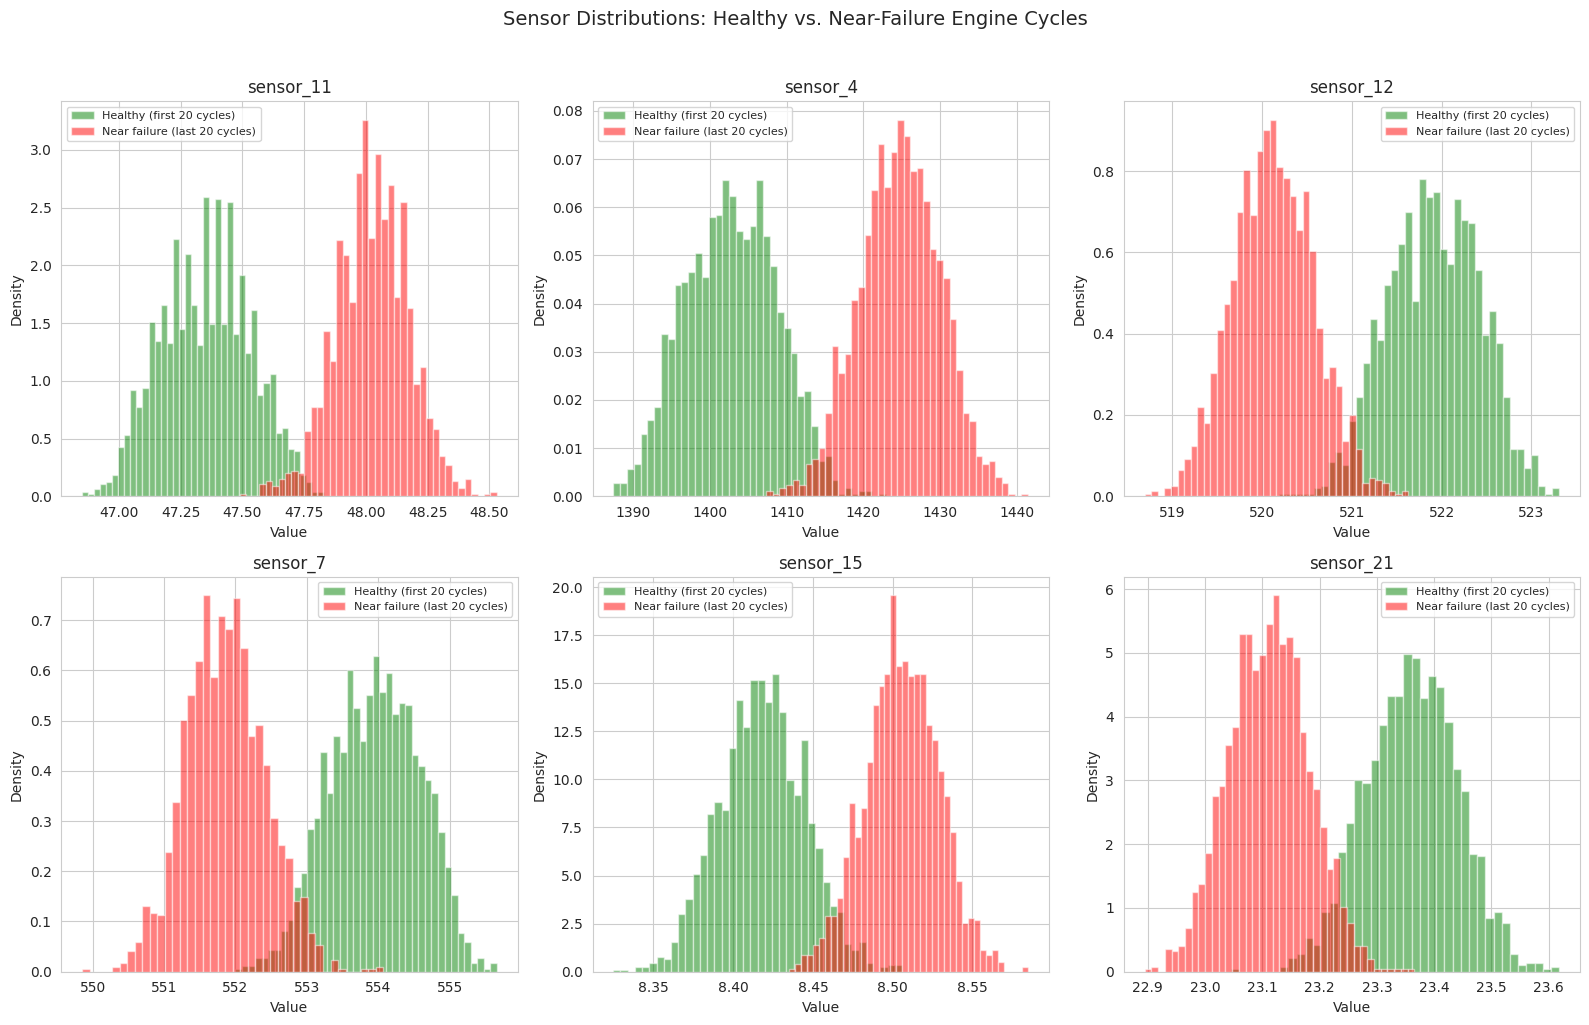

In [9]:
# Compare early-life vs late-life sensor readings
early = train_clean[train_clean['RUL'] > (train_clean.groupby('unit')['RUL'].transform('max') - 20)]
late = train_clean[train_clean['RUL'] <= 20]

# Use the top 6 sensors by RUL correlation
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, sensor in enumerate(top_sensors):
    axes[i].hist(early[sensor], bins=40, alpha=0.5, label='Healthy (first 20 cycles)', color='green', density=True)
    axes[i].hist(late[sensor], bins=40, alpha=0.5, label='Near failure (last 20 cycles)', color='red', density=True)
    axes[i].set_title(sensor)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)

plt.suptitle('Sensor Distributions: Healthy vs. Near-Failure Engine Cycles', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Observation:** The healthy and near-failure distributions are clearly separated for the top sensors, confirming that degradation produces a measurable shift in sensor readings. This separation is exactly what an autoencoder-based anomaly detector would exploit — it would learn the "healthy" distribution and flag near-failure readings as anomalies based on high reconstruction error. The overlap between distributions tells us that a hard threshold would produce some false positives/negatives, motivating a probabilistic or learned approach.

## D.8 RUL Distribution and Smoothed Degradation

We examine the RUL distribution and visualize how a rolling average can reduce sensor noise to reveal clearer degradation trends.

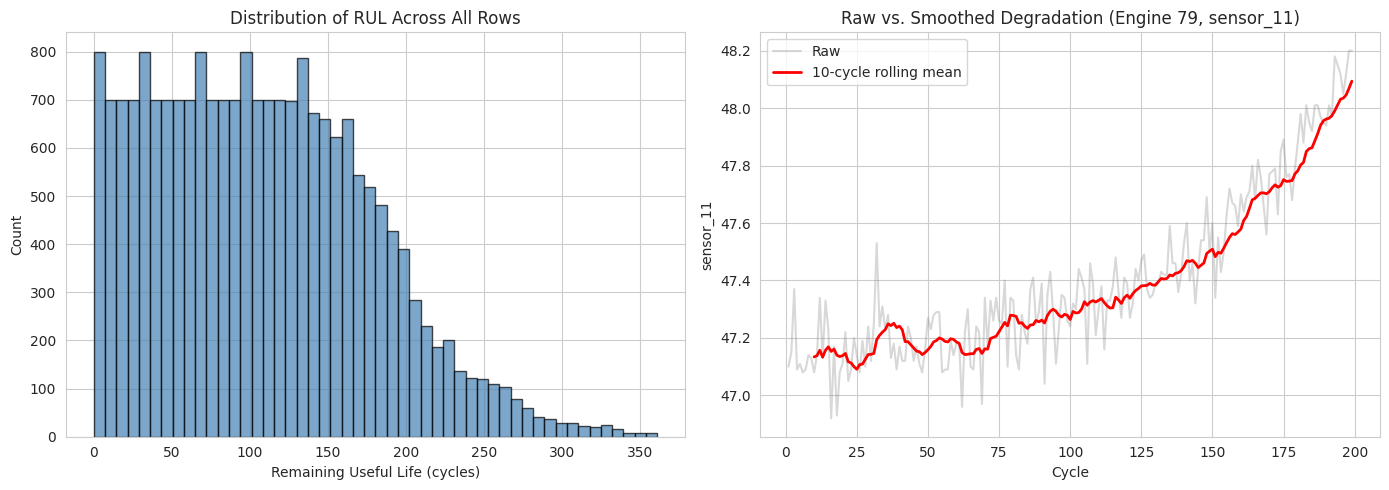

In [10]:
# RUL distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train_clean['RUL'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Remaining Useful Life (cycles)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of RUL Across All Rows')

# Smoothed degradation for one engine using rolling window
engine_id = mid_engine
engine_data = train_clean[train_clean['unit'] == engine_id].copy()
window = 10  # 10-cycle rolling average

axes[1].plot(engine_data['cycle'], engine_data['sensor_11'], alpha=0.3, color='gray', label='Raw')
axes[1].plot(engine_data['cycle'], engine_data['sensor_11'].rolling(window).mean(), 
             color='red', linewidth=2, label=f'{window}-cycle rolling mean')
axes[1].set_xlabel('Cycle')
axes[1].set_ylabel('sensor_11')
axes[1].set_title(f'Raw vs. Smoothed Degradation (Engine {engine_id}, sensor_11)')
axes[1].legend()

plt.tight_layout()
plt.show()

**Observation:** The RUL distribution is roughly uniform by design — since each engine runs from cycle 1 to failure, every RUL value from 0 to (max_lifetime - 1) appears once per engine. The rolling window smoothing dramatically clarifies the degradation trend hidden under sensor noise. A 10-cycle window balances responsiveness with smoothness.

**Decision:** We choose a window size of 10 cycles because it is small enough to preserve the shape of the degradation curve but large enough to average out cycle-to-cycle noise. This will be useful in later stages when engineering features for anomaly detection.

## D.9 PCA — Multivariate Structure

We apply PCA to the normalized informative sensors to see if healthy and degraded states separate in a lower-dimensional space.

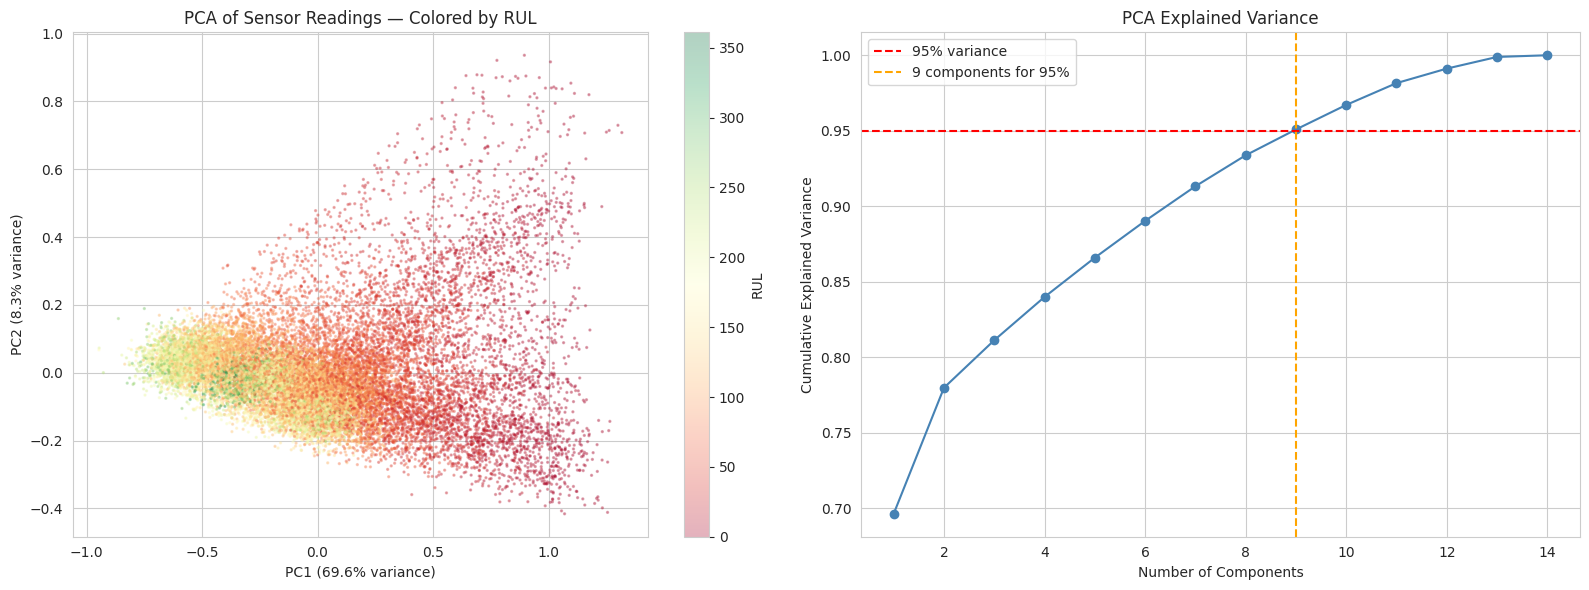

Explained variance by first 2 components: 78.0%
Components needed for 95% variance: 9


In [11]:
# PCA on normalized informative sensors
scaler = MinMaxScaler()
sensor_only = [c for c in informative_cols if c.startswith('sensor_')]
X_scaled = scaler.fit_transform(train_clean[sensor_only])

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Color by RUL
scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=train_clean['RUL'], cmap='RdYlGn', 
                          s=2, alpha=0.3)
plt.colorbar(scatter, ax=axes[0], label='RUL')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[0].set_title('PCA of Sensor Readings — Colored by RUL')

# Explained variance
pca_full = PCA().fit(X_scaled)
cumulative_var = np.cumsum(pca_full.explained_variance_ratio_)
axes[1].plot(range(1, len(cumulative_var) + 1), cumulative_var, 'o-', color='steelblue')
axes[1].axhline(0.95, color='red', linestyle='--', label='95% variance')
n_95 = np.argmax(cumulative_var >= 0.95) + 1
axes[1].axvline(n_95, color='orange', linestyle='--', label=f'{n_95} components for 95%')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('PCA Explained Variance')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Explained variance by first 2 components: {pca.explained_variance_ratio_.sum()*100:.1f}%")
print(f"Components needed for 95% variance: {n_95}")

**Observation:** The PCA projection colored by RUL shows a clear gradient — healthy cycles (green, high RUL) cluster in one region and degraded cycles (red, low RUL) cluster in another. This confirms that degradation is a systematic, multivariate phenomenon that can be captured in a low-dimensional space. The explained variance curve shows that the 14 sensors have significant redundancy — a small number of principal components can capture most of the variance.

**Decision:** We use Min-Max scaling before PCA because the sensors operate on very different scales (sensor_9 ~9,000 vs sensor_15 ~8.4). Without normalization, PCA would be dominated by the largest-valued sensors.

# (E) Initial Insights and Direction

## Key Observations

1. **Degradation is systematic and multivariate:** The top 6 sensors show clear monotonic drift as engines approach failure. This is not random noise — it is a consistent, progressive signal across all 100 engines, confirming that anomaly detection is a well-motivated task for this data.

2. **Sensors are highly redundant:** The correlation heatmap revealed strongly correlated sensor pairs (e.g., sensor_8 and sensor_13), and PCA showed that a small number of components captures most variance. This redundancy means dimensionality reduction is not just useful — it is necessary to avoid multicollinearity in downstream models.

3. **Healthy and degraded states are separable:** The early vs. late life distributions and the PCA projection both show clear separation between healthy engine cycles and near-failure cycles. This directly supports the autoencoder approach — if the model learns the "healthy" manifold, degraded cycles should produce high reconstruction error.

4. **Sensor noise is substantial but manageable:** Raw sensor readings are noisy cycle-to-cycle, but a 10-cycle rolling average reveals clean degradation trends. Feature engineering with rolling statistics (mean, std, slope) will likely improve any downstream model.

5. **No single sensor is sufficient:** The strongest sensor-RUL correlation is ~0.70, meaning no individual sensor can reliably predict failure on its own. Multi-sensor fusion is essential.

## Hypotheses

- **H1:** An autoencoder trained on the first ~30 cycles of each engine (healthy regime) will produce significantly higher reconstruction error on the final ~30 cycles (degraded regime), enabling unsupervised degradation detection without labeled failure data.
- **H2:** Rolling window features (mean, std, slope over a 10–20 cycle window) will produce stronger clustering separation between healthy and degraded states than raw sensor readings.
- **H3:** The redundancy among sensors means that an autoencoder with a narrow bottleneck (e.g., 3–5 latent dimensions) can faithfully reconstruct healthy data while amplifying reconstruction error on degraded data.

## Potential Research Questions

1. **Can an autoencoder reliably detect the onset of degradation without labeled failure data?** — Train on healthy cycles only and evaluate whether reconstruction error rises monotonically as engines approach failure.
2. **How early can degradation be detected?** — At what RUL threshold does the autoencoder first flag an engine as anomalous? Earlier detection is more useful for real-world predictive maintenance.
3. **How do different anomaly detection approaches compare on this data?** — Compare the autoencoder-based approach (beyond course) against traditional methods like isolation forest or distance-based anomaly detection (course topics) to understand the value added by the learned representation.
4. **What is the effect of rolling window size on detection performance?** — Larger windows reduce noise but add detection lag; smaller windows are more responsive but noisier. What is the optimal trade-off?

# (F) GitHub Portfolio

**Repository:** [https://github.com/paurushmani/CSCE676_Project](https://github.com/paurushmani/CSCE676_Project)

The repository contains:
- This checkpoint notebook (`checkpoint1.ipynb`)
- A README describing the project scope, dataset, and planned techniques
- Data loading instructions (the raw data is not committed to the repo due to size)